In [93]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [94]:
import sys

sys.path.insert(1,"../src/")

In [95]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

import acoustic_inversion as ai

from utilities import scramble_nums

In [96]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [97]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

FREQ_RANGE = [250, 400]

In [98]:
with np.load("../data/output/components_arrival_times.npz", allow_pickle=True ) as file1:
    data_components = dict(mode_nos = file1['mode_nos'].squeeze(), peaks_coordinates=file1['peaks_coordinates'])
data_components['mode_nos'] = data_components['mode_nos'] - 1

In [99]:
# in this block, we introduce some perturbation to the mode numbers

data_components['mode_nos'] = scramble_nums(data_components['mode_nos'])

In [100]:
replicas = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")

f = replicas['f'].squeeze()
f_Vg = f[1:-1]
c = replicas['soundspeed'].squeeze()
Vg = replicas['Vg'].squeeze().transpose([1,0,2])
#Vg = Vg[data_components['mode_nos'].squeeze()]
receiver_range = replicas['range'][0,0]*1e3

nmodes, nspeed, nfreq = Vg.shape

In [101]:
f_mask = np.array([f_Vg >= FREQ_RANGE[0],f_Vg <= FREQ_RANGE[1]]).all(0)
regression_f = f_Vg[f_mask]

In [102]:
arrival_times_replica = receiver_range/Vg[...,f_mask]

In [103]:
arrival_times_components = ai.arrival_times_from_peaks(data_components['peaks_coordinates'], regression_f)

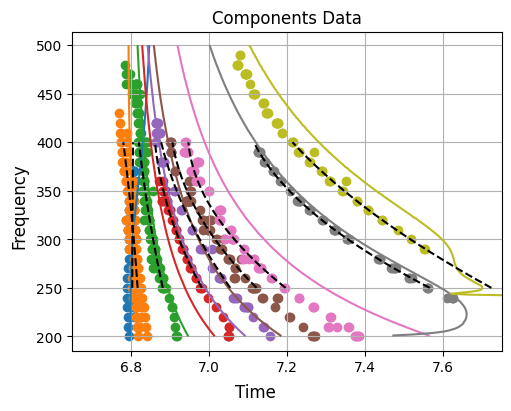

In [104]:
fig, ax_comp = plt.subplots(layout="constrained")

for p in data_components['peaks_coordinates']:
    ax_comp.scatter(p[:,1], p[:,0])
    
ax_comp.plot(receiver_range/Vg[c==TRUE_SOUNDSPEED,data_components['mode_nos'],:].T, f_Vg)
ax_comp.set_prop_cycle(None)
ax_comp.plot(arrival_times_components.T, regression_f, ls='--', c='k')

ax_comp.set_xlim([6.65, 7.75])

ax_comp.grid()

ax_comp.set_title("Components Data")

fig.supylabel("Frequency")
fig.supxlabel("Time")

fig.set_size_inches([5, 4])

In [105]:
fig.savefig("../data/output/mode_curves.png", dpi=600)

In [106]:
l_comp = ai.AcousticInversionLikelihood(arrival_times_components)

## Direct dispersion

In [107]:
lk_direct_comp = l_comp.likelihood_direct(arrival_times_replica[:,data_components['mode_nos']], 0.5e-1)

(29, 9, 151)


Text(0, 0.5, 'Likelihood')

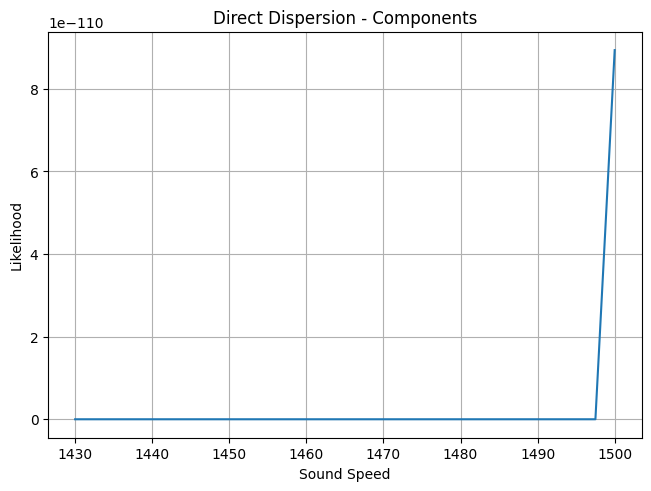

In [108]:
fig, ax = plt.subplots(layout="constrained")

ax.plot(c, lk_direct_comp)
ax.grid()

ax.set_title(f'Direct Dispersion - Components')
ax.set_xlabel('Sound Speed')
ax.set_ylabel('Likelihood')

In [109]:
fig.savefig("../data/output/direct_dispersion.png", dpi=600)

In [110]:
normalize = lambda x: x/np.sum(x)

In [111]:
lk_comp = l_comp.likelihood(arrival_times_replica[:, data_components['mode_nos']], 1e0)

In [112]:
lk_comp = normalize(lk_comp)

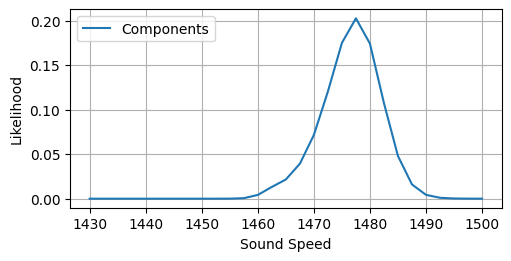

In [113]:
fig, ax = plt.subplots(layout="constrained")

ax.plot(c, lk_comp)
ax.grid()

ax.legend(["Components", "Full"])

ax.set_xlabel("Sound Speed")
ax.set_ylabel("Likelihood")

fig.set_size_inches([5, 2.5])

In [114]:
fig.savefig("../data/output/likelihood_deltas.png", dpi=600)